# Práctico librería implicit - ALS y BPR

Clase: IIC3633 Sistemas Recomendadores, PUC Chile

En este práctico vamos a utilizar la biblioteca de Python [implicit](https://implicit.readthedocs.io/en/latest/quickstart.html) para recomendación utilizando ALS y BPR.


In [108]:
import pandas as pd
import numpy as np
import implicit
import scipy.sparse as sparse

In [109]:
columns = ['movieid', 'title', 'release_date', 'video_release_date', \
           'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', \
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', \
           'Thriller', 'War', 'Western']

In [110]:
# Primero creamos el dataframe con los datos
df_train = pd.read_csv('u2.base',
                         sep='\t',
                         names=['userid', 'itemid', 'rating', 'timestamp'],
                         header=None)

# rating >= 3 , relevante (1) y rating menor a 3 es no relevante (0)
df_train.rating = [1 if x >=3 else 0 for x in df_train.rating ]

In [111]:
df_train.head()

,userid,itemid,rating,timestamp
0,1,3,1,878542960
1,1,4,1,876893119
2,1,5,1,889751712
3,1,6,1,887431973
4,1,7,1,875071561


In [112]:
# Cargamos el dataset con los items
df_items = pd.read_csv('u.item',
                        sep='|',
                        index_col=0,
                        names = columns,
                        header=None,
                        encoding='latin-1')

In [113]:
df_items.head()

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [114]:
# Cargamos el dataset de testing
df_test = pd.read_csv('u2.test',
                      sep='\t',
                      names=['userid', 'itemid', 'rating', 'timestamp'],
                      header=None)


# rating >= 3 es relevante (1) y rating menor a 3 es no relevante (0)
df_test.rating = [1 if x >=3 else 0 for x in df_test.rating ]


user_items_test = {}

for row in df_test.itertuples():
    if row[1] not in user_items_test:
        user_items_test[row[1]] = []

    user_items_test[row[1]].append(row[2])

df_test.head()
# En promedio hay 30 reseñas por usuario en test

,userid,itemid,rating,timestamp
0,1,1,1,874965758
1,1,2,1,876893171
2,1,8,0,875072484
3,1,9,1,878543541
4,1,21,0,878542772


### Métricas

In [115]:
# Definicion de métricas (No editar)

def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()

def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum() # Número de items relevantes
    if n_rel == 0:
        return 0.
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(indices) # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

### Preprocesamiento de los datos a formato sparse

In [116]:
user_items = {}
itemset = set()

for row in df_train.itertuples():
    if row[1] not in user_items:
        user_items[row[1]] = []

    user_items[row[1]].append(row[2])
    itemset.add(row[2])

itemset = np.sort(list(itemset))

sparse_matrix = np.zeros((len(user_items), len(itemset)))

for i, items in enumerate(user_items.values()):
    sparse_matrix[i] = np.isin(itemset, items, assume_unique=True).astype(int)

matrix = sparse.csr_matrix(sparse_matrix.T)

user_ids = {key: i for i, key in enumerate(user_items.keys())}
user_item_matrix = matrix.T.tocsr()

In [117]:
# print(user_ids)
print(user_items[1])
print(user_item_matrix[0]) 

[3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 24, 25, 27, 28, 29, 31, 33, 35, 36, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 69, 70, 71, 72, 73, 74, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 132, 134, 137, 139, 140, 142, 143, 145, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 174, 175, 177, 178, 180, 182, 183, 184, 185, 186, 188, 189, 190, 191, 192, 193, 195, 196, 198, 199, 200, 201, 202, 203, 204, 206, 207, 208, 209, 210, 212, 213, 214, 215, 216, 217, 218, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 235, 236, 238, 240, 241, 242, 243, 244, 245, 248, 250, 251, 252, 253, 254, 255, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267,

In [ ]:
def evaluate_model(model, n):
  mean_ap = 0. # o MAP
  mean_ndcg = 0.
  for u in user_items_test.keys():
    rec = model.recommend(u, user_item_matrix[u], n)[0]
    rel_vector = np.isin(user_items_test[u], rec, assume_unique=True).astype(int)
    mean_ap += average_precision_at_k(rel_vector, n)
    mean_ndcg += ndcg_at_k(rel_vector, n)

  mean_ap /= len(user_items_test)
  mean_ndcg /= len(user_items_test)

  return mean_ap, mean_ndcg


user2id = {user: i for i, user in enumerate(user_items.keys())}
item2id = {item: i for i, item in enumerate(itemset)}     
id2user = {i: user for user, i in user2id.items()}
id2item = {i: item for item, i in item2id.items()}

def evaluate_model(model, n, user_items_test, user_item_matrix, user2id, item2id):
    mean_ap = 0.
    mean_ndcg = 0.

    for orig_user_id in user_items_test.keys():
        u_idx = user2id[orig_user_id]
        rec_indices = model.recommend(userid=u_idx, user_items=user_item_matrix[u_idx], N=n)[0]
        test_item_indices = [item2id[i] for i in user_items_test[orig_user_id] if i in item2id]
        rel_vector = np.isin(test_item_indices, rec_indices, assume_unique=True).astype(int)
        mean_ap += average_precision_at_k(rel_vector, n)
        mean_ndcg += ndcg_at_k(rel_vector, n)

    mean_ap /= len(user_items_test)
    mean_ndcg /= len(user_items_test)

    return mean_ap, mean_ndcg

In [119]:
def show_recommendations(model, user, n):
  recommendations = model.recommend(userid=user, user_items=user_item_matrix[user], N=n)[0]
  return df_items.loc[recommendations]['title']

In [120]:
def show_similar_movies(model, item, n=10):
  sim_items = model.similar_items(item, n)[0]
  return df_items.loc[sim_items]['title']

## ALS (Implicit Feedback)

**Pregunta 1 (2ptos):** Explique brevemente cómo funciona el algoritmo ALS.

**Respuesta:**
Este modelo, enfocado en el feedback implicito, se basa en utilizar datos como cantidad de clicks o visitas para los items. Utilizando estos valores en la matriz usuario/items, en vez de las clasificaciones o ratings. Se parece a FunkSvd pero aprende factores latentes a partir de feedback implicito, de esta manera se incorporan variables binarias de si se interactuo o no y tambien parametros de confianza respecto a que tan "confiable" fue esa interacción del usuario con el item. Otra ventaja de este algoritmo es que factorizando su funcion de perdida se puede paralelizar una gran parte del calculo, reduciendo el costo computacional, pudiendo procesar millones de usuarios e items con menor dificultad. Este modelo al igual que FunkSvd se basa en la factorización matricial para encontrar los factores latentes pero utiliza el metodo "Alternating Least
Squares" para su entrenamiento.

In [132]:
# Definimos y entrenamos el modelo con optimización ALS
model_als = implicit.als.AlternatingLeastSquares(factors=100, iterations=10, use_gpu=False)
model_als.fit(user_item_matrix)

  0%|          | 0/10 [00:00<?, ?it/s]

Ejemplo de recomendación y búsqueda de items similares con los factores latentes ya entrenados:

In [122]:
show_recommendations(model_als, user=77, n=10)

movieid
256     When the Cats Away (Chacun cherche son chat) (...
1012                                 Private Parts (1997)
409                                           Jack (1996)
258                                        Contact (1997)
864                            My Fellow Americans (1996)
49                                            I.Q. (1994)
754                                     Red Corner (1997)
595                                       Fan, The (1996)
273                                           Heat (1995)
404                                      Pinocchio (1940)
Name: title, dtype: object

In [134]:
maprec, ndcg = evaluate_model(model_als, 10, user_items_test, user_item_matrix, user2id, item2id)
print('map: {}\nndcg: {}'.format(maprec, ndcg))

map: 0.3149878422181216
ndcg: 0.37263408355066335


**Pregunta 2 (6ptos):** Pruebe distintos valores (al menos tres combinaciones) para los parámetros de ALS y muestre gráficos de cómo se ven afectadas las métricas recién mostradas.

Para esta pregunta se probaron 48 combinaciones distintas las cuales pueden ser observadas en el codigo inferior. Se demora bastante en correr por lo que sus resultados fueron impresos y hardcoded en la misma variable en el caso de volver a correr el codigo. Luego de esto se puede ver el grafico 3d que muestra los valores de los parametros en los ejes (x e y) y el valor de cada metrica en el eje z. En metricas_als se pueden ver todos los valores obtenidos.

In [124]:
metricas_als = {}
for factor in [25, 50, 75, 100, 125, 150, 175, 200]:
    for iteration in [1, 5, 10, 15, 20, 25]:
        factors = factor
        iterations = iteration
        model_als = implicit.als.AlternatingLeastSquares(factors=factors, iterations=iterations, use_gpu=False)
        model_als.fit(user_item_matrix)
        maprec, ndcg = evaluate_model(model_als, n=10)
        metricas_als[f'{factors}_{iterations}'] = { 'map': maprec , 'ndcg': ndcg }

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
metricas_als = {'25_1': {'map': 0.05163527477172381, 'ndcg': 0.06633629740174349},
 '25_5': {'map': 0.06477466549431389, 'ndcg': 0.0778193978784317},
 '25_10': {'map': 0.06763594654468287, 'ndcg': 0.08165061170055218},
 '25_15': {'map': 0.061867109306387155, 'ndcg': 0.0771070362101208},
 '25_20': {'map': 0.06041122928319191, 'ndcg': 0.07535014399931442},
 '25_25': {'map': 0.060658967942426534, 'ndcg': 0.07315242013522487},
 '50_1': {'map': 0.06132638419518342, 'ndcg': 0.07221713057115903},
 '50_5': {'map': 0.058563899907973914, 'ndcg': 0.07025417322002092},
 '50_10': {'map': 0.06769477535681642, 'ndcg': 0.08024559556864938},
 '50_15': {'map': 0.062288941312698805, 'ndcg': 0.07550610963009305},
 '50_20': {'map': 0.0620035210567722, 'ndcg': 0.07391765537696976},
 '50_25': {'map': 0.06024396807841593, 'ndcg': 0.07384739110081681},
 '75_1': {'map': 0.05732490486382321, 'ndcg': 0.06806377905425001},
 '75_5': {'map': 0.06490762679738954, 'ndcg': 0.076318447058595},
 '75_10': {'map': 0.05963792342038692, 'ndcg': 0.07140955231158176},
 '75_15': {'map': 0.06669657882289508, 'ndcg': 0.07974862227327269},
 '75_20': {'map': 0.06221646164845402, 'ndcg': 0.074679749411606},
 '75_25': {'map': 0.06433842488063087, 'ndcg': 0.07725878791216266},
 '100_1': {'map': 0.0576770000415695, 'ndcg': 0.0738615150418536},
 '100_5': {'map': 0.06131973469213402, 'ndcg': 0.07198978294843102},
 '100_10': {'map': 0.06073619063711363, 'ndcg': 0.07250591282672082},
 '100_15': {'map': 0.0661073309265767, 'ndcg': 0.07787367324911838},
 '100_20': {'map': 0.06890832951803612, 'ndcg': 0.07868653176470292},
 '100_25': {'map': 0.06226463411638828, 'ndcg': 0.07424311998738857},
 '125_1': {'map': 0.055060150392514794, 'ndcg': 0.07052290337269168},
 '125_5': {'map': 0.05390485774638684, 'ndcg': 0.06257894982954157},
 '125_10': {'map': 0.05533398264942923, 'ndcg': 0.06527111409137697},
 '125_15': {'map': 0.05724017633840971, 'ndcg': 0.06770654100125661},
 '125_20': {'map': 0.05794320948289326, 'ndcg': 0.06867900309494285},
 '125_25': {'map': 0.058735933420399386, 'ndcg': 0.06965989747093775},
 '150_1': {'map': 0.061728313388878756, 'ndcg': 0.07346848087062896},
 '150_5': {'map': 0.056697916359569854, 'ndcg': 0.06781524232932384},
 '150_10': {'map': 0.05228840839029748, 'ndcg': 0.06261131494709511},
 '150_15': {'map': 0.04792717146245092, 'ndcg': 0.056585549923357126},
 '150_20': {'map': 0.04620929010396588, 'ndcg': 0.05609786569852012},
 '150_25': {'map': 0.04979169785561289, 'ndcg': 0.05691103997913603},
 '175_1': {'map': 0.06276639680126307, 'ndcg': 0.07783938688431115},
 '175_5': {'map': 0.05265144524164541, 'ndcg': 0.06188698176617849},
 '175_10': {'map': 0.04456336486916226, 'ndcg': 0.048802656727369435},
 '175_15': {'map': 0.049977673524241165, 'ndcg': 0.05351248623043475},
 '175_20': {'map': 0.04612578634131351, 'ndcg': 0.051579389121637474},
 '175_25': {'map': 0.05317846713399071, 'ndcg': 0.059120654939444454},
 '200_1': {'map': 0.06956545301847933, 'ndcg': 0.08369252159415588},
 '200_5': {'map': 0.04717947328457568, 'ndcg': 0.054665575017622085},
 '200_10': {'map': 0.05066849252876068, 'ndcg': 0.05754686038301419},
 '200_15': {'map': 0.04441204044663539, 'ndcg': 0.04944778580156541},
 '200_20': {'map': 0.0418069068040719, 'ndcg': 0.045463507771758636},
 '200_25': {'map': 0.04550519016924865, 'ndcg': 0.05111650351000087}}

Maximo valor de map (eje Z): 0.0696
factores: 200, iteraciones: 1


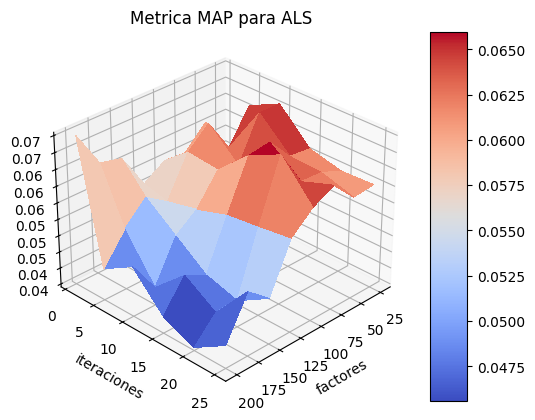

Maximo valor de ndcg (eje Z): 0.0837
factores: 200, iteraciones: 1


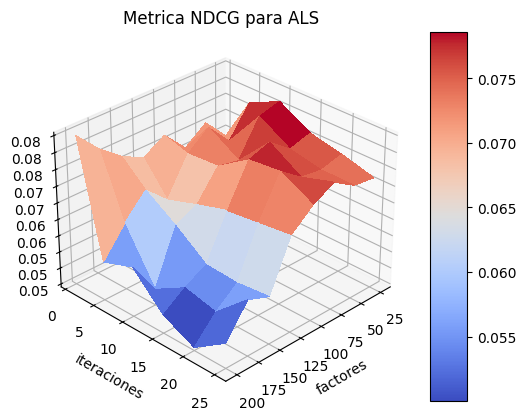

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator

for metrica in ["map", "ndcg"]:
    modelo = "ALS"
    titulo = f"Metrica {(metrica).upper()} para {modelo}"

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

    # Make the data
    x = np.array([25, 50, 75, 100, 125, 150, 175, 200])
    y = np.array([1, 5, 10, 15, 20, 25])
    X, Y = np.meshgrid(x, y)

    z_lista = []
    for iteration in y:
        lista_temporal = []
        for factor in x:
            lista_temporal.append(metricas_als[f'{factor}_{iteration}'][f"{metrica}"])
        z_lista.append(lista_temporal)
    Z = np.array(z_lista)

    # Plot the surface.
    surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

    # Customize the z axis.
    # ax.set_zlim(-1.01, 1.01)
    ax.zaxis.set_major_locator(LinearLocator(10))
    # A StrMethodFormatter is used automatically
    ax.zaxis.set_major_formatter('{x:.02f}')
    # ax.invert_xaxis()
    ax.view_init(elev=30, azim=45)
    ax.set_xlabel("factores")
    ax.set_ylabel("iteraciones")
    ax.set_title(titulo)

    # Add a color bar which maps values to colors.
    fig.colorbar(surf, shrink=1, aspect=10)

    maximo = np.unravel_index(np.argmax(Z), Z.shape)
    max_y_id, max_x_id = maximo
    max_x = x[max_x_id]
    max_y = y[max_y_id]

    print(f"Maximo valor de {metrica} (eje Z): {Z.max():.04f}")
    print(f"factores: {max_x}, iteraciones: {max_y}")
    
    plt.show()

## BPR

**Pregunta 3 (2ptos):** Explique con sus palabras la intuición del framework BPR.

**Respuesta:**
El framework BPR se utiliza para realizar rankings de items en vez de otorgar ratings especificos, se centra en el ordenamiento de estos. BPR no es un algoritmo por si solo sino que forma parte de un framework como la funcion de perdida, esta junto a un modelo y el aprendizaje forman el framework. Este ranking se genera a partir de feedback implicito. Se llama BPR o Bayesian Personalized Ranking porque se basa en una función de perdida la cual se inicia como una distribución de probabilidad conocida apriori que se va modificando a medida que se entrena el modelo obteniendose la distribución aposteriori. De esta manera se puede aprovechar propiedades conocidas de las distribuciones y aplicarlas a los entrenamientos del modelo. Las ventajas es que este framework esta directamente optimizado para la generación de rankings a traves de la maximización de la probabilidad de la distribución aposteriori del analisis bayesiano del problema. Una gran ventaja es que al realizar sampling de los datos al momento de entrenar, sin necesidad de cubrir a todos lo usuarios, sus metricas mejoran rapidamente a las pocas iteraciones.

In [ ]:
# Definimos y entrenamos el modelo de implicit feedback utilizando optimizacion BPR
model_bpr = implicit.bpr.BayesianPersonalizedRanking(factors=400, iterations=40, use_gpu=False)
model_bpr.fit(user_item_matrix)

  0%|          | 0/40 [00:00<?, ?it/s]

Ejemplo de recomendación y búsqueda de items similares con los factores latentes ya entrenados:

In [ ]:
show_recommendations(model_bpr, user=77, n=10)

movieid
285                     Secrets & Lies (1996)
257                       Men in Black (1997)
327                           Cop Land (1997)
299                            Hoodlum (1997)
746                        Real Genius (1985)
301                           In & Out (1997)
244             Smilla's Sense of Snow (1997)
267                                   unknown
99     Snow White and the Seven Dwarfs (1937)
332                     Kiss the Girls (1997)
Name: title, dtype: object

In [ ]:
show_similar_movies(model_bpr, item=171, n=10)

movieid
171                                Delicatessen (1991)
209                          This Is Spinal Tap (1984)
27                                     Bad Boys (1995)
203                                  Unforgiven (1992)
68                                    Crow, The (1994)
172                    Empire Strikes Back, The (1980)
201                                Evil Dead II (1987)
650    Seventh Seal, The (Sjunde inseglet, Det) (1957)
173                         Princess Bride, The (1987)
194                                  Sting, The (1973)
Name: title, dtype: object

In [ ]:
maprec, ndcg = evaluate_model(model_bpr, n=10)
print('map: {}\nndcg: {}'.format(maprec, ndcg))

map: 0.05266658048996394
ndcg: 0.06981848403466916


**Pregunta 4 (6ptos):** Pruebe distintos valores (al menos tres combinaciones) para los parámetros de BPR y muestre gráficos de cómo se ven afectadas las métricas de ranking (nDCG@10 y MAP) recién mostradas.

Para esta pregunta se probaron 48 combinaciones distintas las cuales pueden ser observadas en el codigo inferior. Se demora un poco en correr por lo que sus resultados fueron impresos y hardcoded en la misma variable en el caso de volver a correr el codigo. Luego de esto se puede ver el grafico 3d que muestra los valores de los parametros en los ejes (x e y) y el valor de cada metrica en el eje z. En metricas_bpr se pueden ver todos los valores obtenidos.

In [ ]:
metricas_bpr = {}
for factor in [100, 200, 300, 400, 500, 600, 700, 800]:
    for iteration in [20, 30, 40, 50, 60, 70]:
        factors = factor
        iterations = iteration
        model_bpr = implicit.bpr.BayesianPersonalizedRanking(factors=factors, iterations=iterations, use_gpu=False)
        model_bpr.fit(user_item_matrix)
        maprec, ndcg = evaluate_model(model_bpr, n=10)
        metricas_bpr[f'{factors}_{iterations}'] = { 'map': maprec , 'ndcg': ndcg }

In [ ]:
metricas_bpr = {'100_20': {'map': 0.057217598001264997, 'ndcg': 0.07621632230443574},
 '100_30': {'map': 0.052559428623963185, 'ndcg': 0.06832010338728987},
 '100_40': {'map': 0.046448850307563704, 'ndcg': 0.05981819540957986},
 '100_50': {'map': 0.05556957355685653, 'ndcg': 0.06670256645239943},
 '100_60': {'map': 0.04889419647886613, 'ndcg': 0.05969317355056041},
 '100_70': {'map': 0.047376393086407384, 'ndcg': 0.05735609999154543},
 '200_20': {'map': 0.045774033421079434, 'ndcg': 0.06183959455005829},
 '200_30': {'map': 0.046115467385499646, 'ndcg': 0.0624601217727027},
 '200_40': {'map': 0.049912456290297946, 'ndcg': 0.06226224126244506},
 '200_50': {'map': 0.047091995430605486, 'ndcg': 0.05825552041524988},
 '200_60': {'map': 0.05368112595919696, 'ndcg': 0.06564284141271971},
 '200_70': {'map': 0.04235268131775326, 'ndcg': 0.05133811116822327},
 '300_20': {'map': 0.05131390820689493, 'ndcg': 0.06901102205397103},
 '300_30': {'map': 0.05717223912109704, 'ndcg': 0.07466182689185635},
 '300_40': {'map': 0.03937668906723656, 'ndcg': 0.04903759609032122},
 '300_50': {'map': 0.045540165357235, 'ndcg': 0.058706574484758633},
 '300_60': {'map': 0.0500248197850805, 'ndcg': 0.06319772099134702},
 '300_70': {'map': 0.03930100641793569, 'ndcg': 0.047903125624247415},
 '400_20': {'map': 0.05925614738679818, 'ndcg': 0.0759569671500544},
 '400_30': {'map': 0.05715653399976278, 'ndcg': 0.07555713855638287},
 '400_40': {'map': 0.044808131363981867, 'ndcg': 0.058170188729921815},
 '400_50': {'map': 0.0422179388683106, 'ndcg': 0.05044427029282703},
 '400_60': {'map': 0.04937263616329673, 'ndcg': 0.05966576310485271},
 '400_70': {'map': 0.04633870251422715, 'ndcg': 0.05598941538700482},
 '500_20': {'map': 0.04652451201009314, 'ndcg': 0.06142290523336188},
 '500_30': {'map': 0.06005249725478203, 'ndcg': 0.07816151655481601},
 '500_40': {'map': 0.05136368672783094, 'ndcg': 0.06523392314904398},
 '500_50': {'map': 0.048135275845590624, 'ndcg': 0.060922019554028116},
 '500_60': {'map': 0.04422290211793968, 'ndcg': 0.05477725428589271},
 '500_70': {'map': 0.048846661184427376, 'ndcg': 0.058783188410108926},
 '600_20': {'map': 0.05490961874799874, 'ndcg': 0.07112799474725162},
 '600_30': {'map': 0.054875590833628314, 'ndcg': 0.07249771676937093},
 '600_40': {'map': 0.04876067853198181, 'ndcg': 0.06379009240577924},
 '600_50': {'map': 0.046882040422781934, 'ndcg': 0.05947342638942597},
 '600_60': {'map': 0.050525334681075326, 'ndcg': 0.061833958771684114},
 '600_70': {'map': 0.046106171799005224, 'ndcg': 0.05754481777648921},
 '700_20': {'map': 0.04610677014783316, 'ndcg': 0.06273260053246595},
 '700_30': {'map': 0.04951868528671652, 'ndcg': 0.06637279816448649},
 '700_40': {'map': 0.05252465520315419, 'ndcg': 0.0677500053623678},
 '700_50': {'map': 0.047198627872890614, 'ndcg': 0.058098664717430956},
 '700_60': {'map': 0.048120659981491516, 'ndcg': 0.061340860737881434},
 '700_70': {'map': 0.04069672240735684, 'ndcg': 0.051007011712270914},
 '800_20': {'map': 0.04881774366867823, 'ndcg': 0.06525514264636902},
 '800_30': {'map': 0.05944296762141508, 'ndcg': 0.0769153269482441},
 '800_40': {'map': 0.049982652994502275, 'ndcg': 0.06351293854722621},
 '800_50': {'map': 0.041916123697004926, 'ndcg': 0.05534463227315613},
 '800_60': {'map': 0.044116361062912876, 'ndcg': 0.0548738253239185},
 '800_70': {'map': 0.04398840786084737, 'ndcg': 0.052746631523890836}}

Maximo valor de map (eje Z): 0.0601
factores: 500, iteraciones: 30


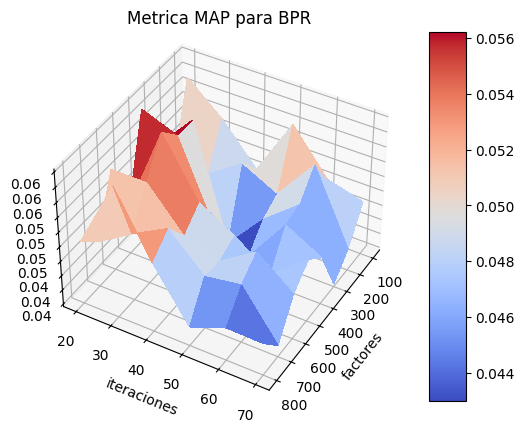

Maximo valor de ndcg (eje Z): 0.0782
factores: 500, iteraciones: 30


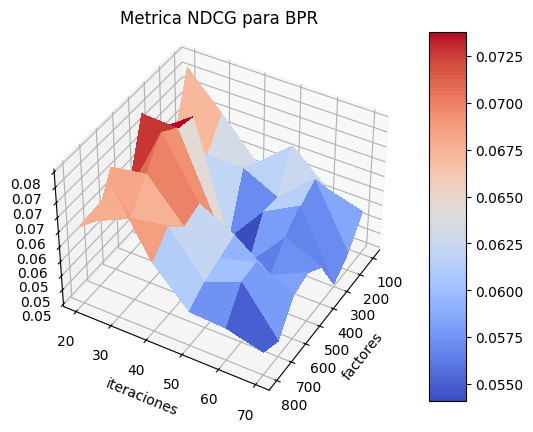

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator

for metrica in ["map", "ndcg"]:
    modelo = "BPR"
    titulo = f"Metrica {(metrica).upper()} para {modelo}"

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

    # Make the data
    x = np.array([100, 200, 300, 400, 500, 600, 700, 800])
    y = np.array([20, 30, 40, 50, 60, 70])
    X, Y = np.meshgrid(x, y)

    z_lista = []
    for iteration in y:
        lista_temporal = []
        for factor in x:
            lista_temporal.append(metricas_bpr[f'{factor}_{iteration}'][f"{metrica}"])
        z_lista.append(lista_temporal)
    Z = np.array(z_lista)

    # Plot the surface.
    surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                        linewidth=0, antialiased=False)

    # Customize the z axis.
    # ax.set_zlim(-1.01, 1.01)
    ax.zaxis.set_major_locator(LinearLocator(10))
    # A StrMethodFormatter is used automatically
    ax.zaxis.set_major_formatter('{x:.02f}')
    # ax.invert_xaxis()
    ax.view_init(elev=40, azim=30)
    ax.set_xlabel("factores")
    ax.set_ylabel("iteraciones")
    ax.set_title(titulo)

    # Add a color bar which maps values to colors.
    fig.colorbar(surf, shrink=1, aspect=10)

    maximo = np.unravel_index(np.argmax(Z), Z.shape)
    max_y_id, max_x_id = maximo
    max_x = x[max_x_id]
    max_y = y[max_y_id]

    print(f"Maximo valor de {metrica} (eje Z): {Z.max():.04f}")
    print(f"factores: {max_x}, iteraciones: {max_y}")
    
    plt.show()